<a href="https://colab.research.google.com/github/PRINCEGOTI12/Bitcoin-Price-Predication/blob/main/DRL_PROJECT_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📈 Bitcoin Price Prediction Using LSTM (2014–2024)**

# ✅ Overview

This project uses a Long Short-Term Memory (LSTM) model to predict Bitcoin (BTC-USD) closing prices over a 10-year span (2014–2024). The approach involves:


*   Preprocessing historical price data
*   Creating training and testing datasets

*   Building and training an LSTM neural network
*   Evaluating model performance

*   Visualizing atual vs. predicted values
*   Forecasting a future price


# 🧹 Step 1: Data Loading & Visualization

* Loaded the historical Bitcoin price dataset from 2014 to 2024.
* Selected only the 'Date' and 'Close' columns.
* Plotted the closing price trend using Plotly for interactive visualization.

# ⚙️ Step 2: Data Preprocessing
* Removed the 'Date' column for training.

* Normalized the close prices between 0 and 1 using MinMaxScaler.

* Split the data: 60% training, 40% testing.

* Created sequences of 15 previous time steps (lags) as input features for the LSTM.

# 🧠 Step 3: Model Architecture
* Built a sequential LSTM model using Keras:

* Input Layer: Shape = (15 time steps, 1 feature)

* LSTM Layer: 10 units with tanh activation

* Dense Output Layer: 1 neuron for price prediction

* Loss Function: Mean Squared Error (MSE)

* Optimizer: Adam

Used EarlyStopping to prevent overfitting by monitoring val_loss.

# 🚀 Step 4: Model Training
* Trained the model for a maximum of 150 epochs with batch size 32.

* EarlyStopping helped stop training once validation loss stopped improving.

# 🔍 Step 5: Model Evaluation
* Predicted both training and testing data.

* Inverse-transformed predictions to original price scale.

* Evaluated using:
    * Root Mean Squared Error (RMSE)
    * Accuracy (based on Mean Absolute Percentage Error - MAPE)


# 📊 Step 6: Visualization
* Plotted actual prices vs. predicted prices (train and test) using both Matplotlib and Plotly.

* Used placeholders to align predictions with the original price timeline.

# 🔮 Step 7: Future Price Prediction
* Predicted the next day Bitcoin closing price using the last 15 test points.
* Output shown after inverse transformation.

# 📉 Step 8: Training & Validation Loss Plot
* Visualized loss curves to show training progression and detect overfitting.



Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0021 - val_loss: nan
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.3198e-05 - val_loss: nan
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.6060e-05 - val_loss: nan
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.4487e-05 - val_loss: nan
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.2781e-05 - val_loss: nan
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0976e-05 - val_loss: nan
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.9179e-05 - val_loss: nan
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.7479e-05 - val_loss: nan
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.5900e-05 - val_loss: nan
Epoch 10/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4428e-05 - val_loss: nan
Epoch 11/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.3042e-05 - val_loss: nan
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
43/43

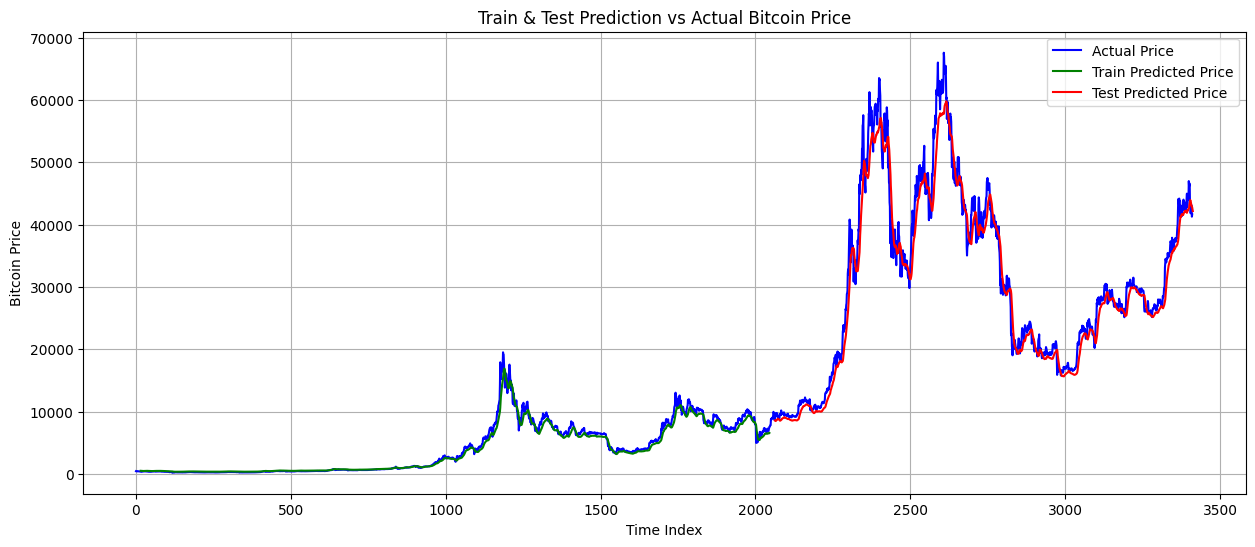

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Future Predicted Bitcoin Price: nan


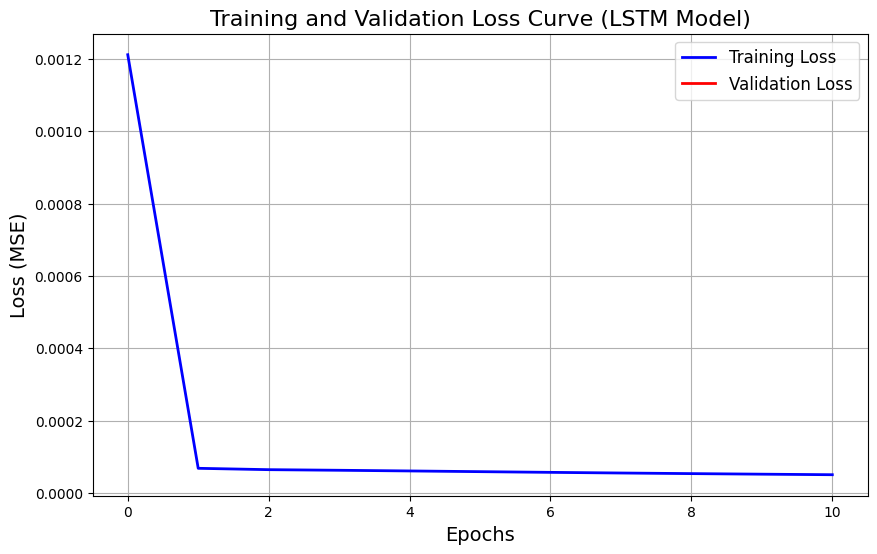

In [ ]:
## LSTM model

import os
import pandas as pd
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

import plotly.graph_objects as go
import plotly.express as px

# Ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
maindf = pd.read_csv("/content/drive/MyDrive/BTC-USD (2014-2024).csv")
closedf = maindf[['Date','Close']]

# Plot initial data
fig = px.line(closedf, x=closedf.Date, y=closedf.Close,
              labels={'date':'Date','close':'Close Stock'})
fig.update_layout(title_text='Whole period of timeframe of Bitcoin close price 2014-2024')
fig.show()

# Preprocessing
del closedf['Date']
scaler = MinMaxScaler(feature_range=(0,1))
closedf = scaler.fit_transform(np.array(closedf).reshape(-1,1))

training_size = int(len(closedf)*0.60)
test_size = len(closedf) - training_size
train_data, test_data = closedf[0:training_size], closedf[training_size:]

# Dataset preparation
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 15
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build model
model = Sequential()
model.add(Input(shape=(None, 1)))
model.add(LSTM(10, activation='tanh'))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam")

# Fit model with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=150, batch_size=32, verbose=1, callbacks=[early_stop])

# Predict and inverse scale
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

#Handle potential NaNs in predictions before inverse scaling
train_predict = np.nan_to_num(train_predict, nan=0.0)
test_predict = np.nan_to_num(test_predict, nan=0.0)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1, 1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1, 1))

#Handle potential NaNs in the original target values as well
original_ytrain = np.nan_to_num(original_ytrain, nan=0.0)
original_ytest = np.nan_to_num(original_ytest, nan=0.0)

# Evaluation
print("Train data RMSE:", math.sqrt(mean_squared_error(original_ytrain, train_predict)))
print("Test data RMSE: ", math.sqrt(mean_squared_error(original_ytest, test_predict)))

# Mean Absolute Percentage Error (MAPE) based accuracy
def calculate_accuracy(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    mask = actual > 1e-8
    if np.sum(mask) == 0:
        return 0
    filtered_actual = actual[mask]
    filtered_predicted = predicted[mask]
    mape = np.mean(np.abs((filtered_actual - filtered_predicted) / filtered_actual)) * 100
    accuracy = 100 - mape
    return accuracy


train_accuracy = calculate_accuracy(original_ytrain, train_predict)
test_accuracy = calculate_accuracy(original_ytest, test_predict)

print("Train data Accuracy (based on MAPE): {:.2f}%".format(train_accuracy))
print("Test data Accuracy (based on MAPE):  {:.2f}%".format(test_accuracy))

# Create prediction placeholders for plotting
train_predict_plot = np.empty_like(closedf)
train_predict_plot[:, :] = np.nan
train_predict_plot[time_step:training_size-1, :] = train_predict

test_predict_plot = np.empty_like(closedf)
test_predict_plot[:, :] = np.nan
test_predict_plot[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict), :] = test_predict

# Actual inverse-scaled data for comparison
actual_data_plot = scaler.inverse_transform(closedf)

# Plot using Matplotlib
plt.figure(figsize=(15,6))
plt.plot(actual_data_plot, label='Actual Price', color='blue')
plt.plot(train_predict_plot, label='Train Predicted Price', color='green')
plt.plot(test_predict_plot, label='Test Predicted Price', color='red')
plt.xlabel("Time Index")
plt.ylabel("Bitcoin Price")
plt.title("Train & Test Prediction vs Actual Bitcoin Price")
plt.legend()
plt.grid(True)
plt.show()

# Interactive Plotly chart
time_index = maindf['Date']
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_index, y=actual_data_plot.flatten(), mode='lines', name='Actual Price', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=time_index[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict)],
                         y=test_predict.flatten(), mode='lines', name='Test Predicted Price', line=dict(color='red')))
fig.update_layout(title='Actual vs Predicted Bitcoin Price (2014–2024)',
                  xaxis_title='Date', yaxis_title='Price',
                  plot_bgcolor='white')
fig.show()

# Prediction for future value
x_input = test_data[-time_step:].reshape(1, -1)
x_input = x_input.reshape((1, time_step, 1))
future_pred = model.predict(x_input)
future_pred_value = scaler.inverse_transform(future_pred)
print("Future Predicted Bitcoin Price:", future_pred_value[0][0])

# Plot Training and Validation Loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss Curve (LSTM Model)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()



In [ ]:
## LSTM model forecasting for next 30 days

if np.isnan(x_input).any():
    nan_indices = np.where(np.isnan(x_input))
    for i in range(len(nan_indices[0])):
        idx = nan_indices[1][i]
        valid_values = x_input[0][~np.isnan(x_input[0, :, 0]), 0]
        x_input[0, idx, 0] = np.mean(valid_values)

print("x_input shape:", x_input.shape)
print("x_input:", x_input)
print("NaNs in x_input?", np.isnan(x_input).any())
print("Infs in x_input?", np.isinf(x_input).any())

x_input = test_data[-time_step:].reshape(1, time_step, 1)

# Reshape last time_step data from test_data for prediction
x_input = test_data[-time_step:].reshape(1, time_step, 1)

# Sanitize just in case
x_input = np.nan_to_num(x_input, nan=0.0, posinf=0.0, neginf=0.0)

# Predict and inverse transform
future_pred = model.predict(x_input)
future_pred_value = scaler.inverse_transform(future_pred)

print("Future Predicted Bitcoin Price:", future_pred_value[0][0])


# Start with last time_step days from test_data
temp_input = list(test_data[-time_step:].flatten())
temp_input = [x if not np.isnan(x) else 0.0 for x in temp_input]
future_output = []
n_steps = time_step
future_days = 30
for i in range(future_days):
    x_input = np.array(temp_input[-n_steps:]).reshape(1, n_steps, 1)
    y_pred = model.predict(x_input, verbose=0)
    temp_input.append(y_pred[0][0])
    future_output.append(y_pred[0][0])
future_output = scaler.inverse_transform(np.array(future_output).reshape(-1, 1))
last_date = pd.to_datetime(maindf['Date'].iloc[-1])
future_dates = [last_date + dt.timedelta(days=i+1) for i in range(future_days)]

# Convert future_dates to strings for Matplotlib
future_dates_str = [d.strftime('%Y-%m-%d') for d in future_dates]

# Plot predictions
last_date = pd.to_datetime(maindf['Date'].iloc[-1])
future_days = 30
future_dates = [last_date + dt.timedelta(days=i+1) for i in range(future_days)]
time_index = maindf['Date']
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_index, y=scaler.inverse_transform(closedf).flatten(),
                         mode='lines', name='Historical Price', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=time_index[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict)],
                         y=test_predict.flatten(), mode='lines',
                         name='Test Predicted Price', line=dict(color='red')))
fig.add_trace(go.Scatter(x=future_dates, y=future_output.flatten(),
                         mode='lines', name='Next 30-Day Forecast', line=dict(color='orange', dash='dash')))  # Use dash for linestyle
fig.update_layout(title='Bitcoin Price Forecast for Next 30 Days [LSTM Model]',
                  xaxis_title='Date', yaxis_title='Price',
                  plot_bgcolor='white')
fig.show()

# Create DataFrame for next 30 days forecast
forecast_df = pd.DataFrame({
    'Date': future_dates_str,
    'Predicted Price': future_output.flatten()
})

# Display the DataFrame
print(forecast_df)


x_input shape: (1, 15, 1)
x_input: [[[0.587915  ]
  [0.58595455]
  [0.5839196 ]
  [0.5819007 ]
  [0.5799079 ]
  [0.5779369 ]
  [0.5759863 ]
  [0.57405293]
  [0.5721271 ]
  [0.57020915]
  [0.56829745]
  [0.5663948 ]
  [0.564503  ]
  [0.5626208 ]
  [0.56074524]]]
NaNs in x_input? False
Infs in x_input? False
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Future Predicted Bitcoin Price: 41941.656


          Date  Predicted Price
0   2024-01-22     41941.656250
1   2024-01-23     41786.378906
2   2024-01-24     41583.312500
3   2024-01-25     41394.523438
4   2024-01-26     41204.542969
5   2024-01-27     41023.945312
6   2024-01-28     40890.722656
7   2024-01-29     40756.421875
8   2024-01-30     40632.578125
9   2024-01-31     40496.453125
10  2024-02-01     40350.687500
11  2024-02-02     40209.820312
12  2024-02-03     40086.007812
13  2024-02-04     39954.480469
14  2024-02-05     39796.945312
15  2024-02-06     39664.832031
16  2024-02-07     39527.699219
17  2024-02-08     39391.652344
18  2024-02-09     39257.355469
19  2024-02-10     39124.535156
20  2024-02-11     38993.085938
21  2024-02-12     38862.796875
22  2024-02-13     38733.019531
23  2024-02-14     38603.769531
24  2024-02-15     38474.945312
25  2024-02-16     38346.726562
26  2024-02-17     38219.242188
27  2024-02-18     38092.402344
28  2024-02-19     37966.011719
29  2024-02-20     37840.167969



# **📈 Bitcoin Price Prediction Using GRU (2014–2024)**
# ✅ Overview
This project implements a Gated Recurrent Unit (GRU) based deep learning model to predict Bitcoin (BTC-USD) closing prices from 2014 to 2024. The process includes:

* Preprocessing historical BTC price data

* Creating time-sequenced datasets for supervised learning

* Designing and training a GRU-based neural network

* Evaluating the model using RMSE and MAPE-based accuracy

* Visualizing predictions vs. actual prices

* Forecasting the next-day Bitcoin closing price

# 🧹 Step 1: Data Loading & Visualization
* Loaded Bitcoin price dataset from 2014 to 2024.

* Focused only on the 'Date' and 'Close' columns.

* Used Plotly to create an interactive chart showing historical closing price trends.

# ⚙️ Step 2: Data Preprocessing
* Removed the non-numeric 'Date' column.

* Applied MinMaxScaler to normalize closing prices between 0 and 1.

* Split data into 60% training and 40% testing.

* Created sequences of 15 previous time steps as input for the GRU model.

# 🧠 Step 3: Model Architecture
The model is built using Keras and has the following structure:

  * Input Layer: Accepts sequences of shape (15 time steps, 1 feature)

  * GRU Layer 1: 64 units with tanh activation and return_sequences=True

  * GRU Layer 2: 32 units with tanh activation

* Dense Output Layer: 1 unit for final price prediction

* Loss Function: Mean Squared Error (MSE)

* Optimizer: Adam

Also implemented EarlyStopping to prevent overfitting by monitoring the validation loss.

# 🚀 Step 4: Model Training
* Trained over 150 epochs with a batch size of 32.

* EarlyStopping automatically stopped training when the model stopped improving on validation loss.

# 🔍 Step 5: Model Evaluation
* Used the trained model to predict on both training and test data.

* Converted predictions back to the original scale using inverse transform.

* Evaluated model performance using:

    * RMSE (Root Mean Squared Error)

    * MAPE-based Accuracy: Interpreted as percentage correctness of prediction

# 📊 Step 6: Visualization
* Plotted actual vs predicted values for both training and test data using:

    * Matplotlib (static visualization)

    * Plotly (interactive visualization)

* Created prediction placeholders to align predicted data on the original timeline.

#🔮 Step 7: Future Price Prediction
* Used the last 15 points of the test set to predict the next day’s Bitcoin closing price.

* Final output was inverse scaled to present the value in the original price format.

# 📉 Step 8: Training & Validation Loss Plot
* Plotted both training and validation loss curves to visualize learning dynamics.

* Helped confirm effective training and detect potential overfitting.



Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0018 - val_loss: nan
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 3.8846e-05 - val_loss: nan
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3.4789e-05 - val_loss: nan
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 3.2401e-05 - val_loss: nan
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3.1195e-05 - val_loss: nan
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.9763e-05 - val_loss: nan
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.8298e-05 - val_loss: nan
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.6724e-05 - val_loss: nan
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 2.5344e-05 - val_loss: nan
Epoch 10/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 2.4377e-05 - val_loss: nan
Epoch 11/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 2.3702e-05 - val_loss: nan
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
43/43

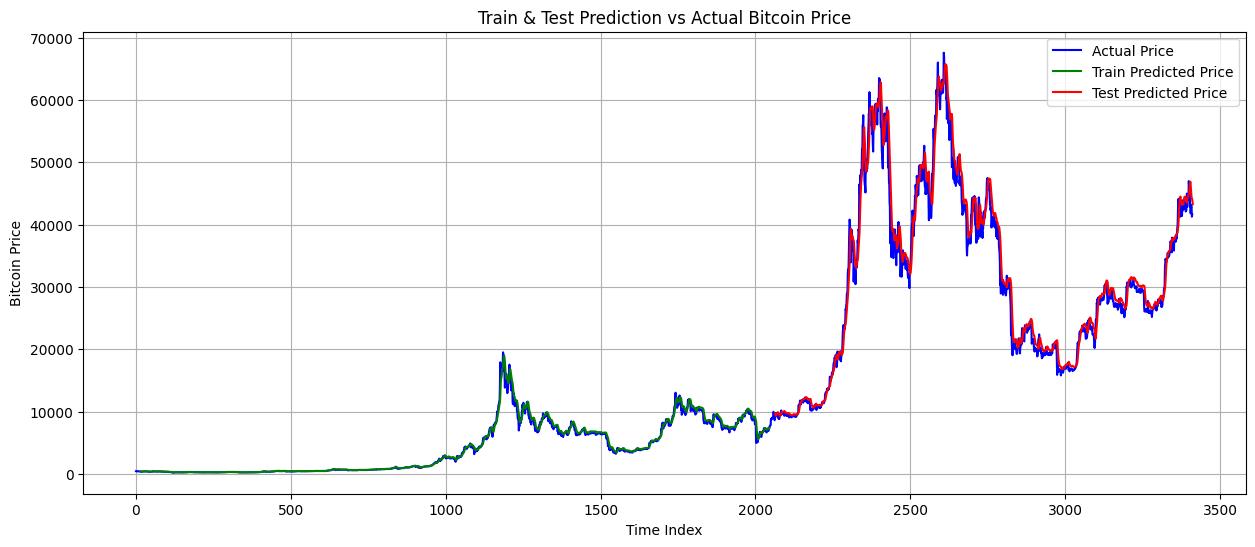

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Future Predicted Bitcoin Price: nan


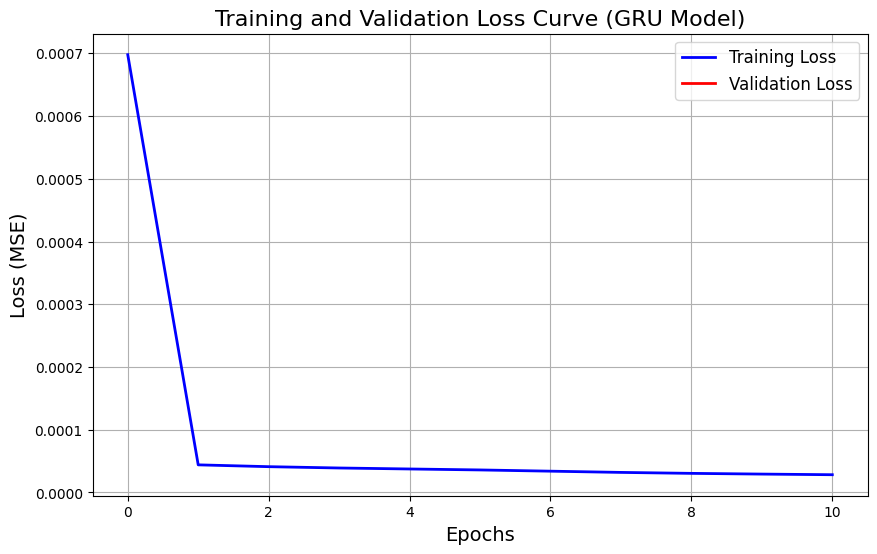

In [ ]:
##GRU model

import os
import pandas as pd
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

import plotly.graph_objects as go
import plotly.express as px

# Ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
maindf = pd.read_csv("/content/drive/MyDrive/BTC-USD (2014-2024).csv")
closedf = maindf[['Date','Close']]

# Plot initial data
fig = px.line(closedf, x=closedf.Date, y=closedf.Close,
              labels={'date':'Date','close':'Close Stock'})
fig.update_layout(title_text='Whole period of timeframe of Bitcoin close price 2014-2024')
fig.show()

# Preprocessing
del closedf['Date']
scaler = MinMaxScaler(feature_range=(0,1))
closedf = scaler.fit_transform(np.array(closedf).reshape(-1,1))

training_size = int(len(closedf)*0.60)
test_size = len(closedf) - training_size
train_data, test_data = closedf[0:training_size], closedf[training_size:]

# Dataset preparation
def create_dataset(dataset, time_step=15):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 15
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build GRU model
model = Sequential()
model.add(Input(shape=(None, 1)))
model.add(GRU(64, activation='tanh', return_sequences=True))
model.add(GRU(32, activation='tanh'))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam")

# Fit model with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=150, batch_size=32, verbose=1, callbacks=[early_stop])

# Predict and inverse scale
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = np.nan_to_num(train_predict, nan=0.0)
test_predict = np.nan_to_num(test_predict, nan=0.0)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1, 1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1, 1))

original_ytrain = np.nan_to_num(original_ytrain, nan=0.0)
original_ytest = np.nan_to_num(original_ytest, nan=0.0)

# Evaluation
print("Train data RMSE:", math.sqrt(mean_squared_error(original_ytrain, train_predict)))
print("Test data RMSE: ", math.sqrt(mean_squared_error(original_ytest, test_predict)))

def calculate_accuracy(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    mask = actual > 1e-8
    if np.sum(mask) == 0:
        return 0
    filtered_actual = actual[mask]
    filtered_predicted = predicted[mask]
    mape = np.mean(np.abs((filtered_actual - filtered_predicted) / filtered_actual)) * 100
    accuracy = 100 - mape
    return accuracy

train_accuracy = calculate_accuracy(original_ytrain, train_predict)
test_accuracy = calculate_accuracy(original_ytest, test_predict)

print("Train data Accuracy (based on MAPE): {:.2f}%".format(train_accuracy))
print("Test data Accuracy (based on MAPE):  {:.2f}%".format(test_accuracy))


# Create prediction placeholders for plotting
train_predict_plot = np.empty_like(closedf)
train_predict_plot[:, :] = np.nan
train_predict_plot[time_step:training_size-1, :] = train_predict

test_predict_plot = np.empty_like(closedf)
test_predict_plot[:, :] = np.nan
test_predict_plot[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict), :] = test_predict

# Actual inverse-scaled data for comparison
actual_data_plot = scaler.inverse_transform(closedf)

# Plot using Matplotlib
plt.figure(figsize=(15,6))
plt.plot(actual_data_plot, label='Actual Price', color='blue')
plt.plot(train_predict_plot, label='Train Predicted Price', color='green')
plt.plot(test_predict_plot, label='Test Predicted Price', color='red')
plt.xlabel("Time Index")
plt.ylabel("Bitcoin Price")
plt.title("Train & Test Prediction vs Actual Bitcoin Price")
plt.legend()
plt.grid(True)
plt.show()

# Interactive Plotly chart
time_index = maindf['Date']
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_index, y=actual_data_plot.flatten(), mode='lines', name='Actual Price', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=time_index[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict)],
                         y=test_predict.flatten(), mode='lines', name='Test Predicted Price', line=dict(color='red')))
fig.update_layout(title='Actual vs Predicted Bitcoin Price (2014–2024)',
                  xaxis_title='Date', yaxis_title='Price',
                  plot_bgcolor='white')
fig.show()

# Prediction for future value
x_input = test_data[-time_step:].reshape(1, -1)
x_input = x_input.reshape((1, time_step, 1))
future_pred = model.predict(x_input)
future_pred_value = scaler.inverse_transform(future_pred)
print("Future Predicted Bitcoin Price:", future_pred_value[0][0])

# Plot Training and Validation Loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss Curve (GRU Model)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()



In [ ]:
## GRU model forecasting for next 30 days

if np.isnan(x_input).any():
    nan_indices = np.where(np.isnan(x_input))
    for i in range(len(nan_indices[0])):
        idx = nan_indices[1][i]
        valid_values = x_input[0][~np.isnan(x_input[0, :, 0]), 0]
        x_input[0, idx, 0] = np.mean(valid_values)

print("x_input shape:", x_input.shape)
print("x_input:", x_input)
print("NaNs in x_input?", np.isnan(x_input).any())
print("Infs in x_input?", np.isinf(x_input).any())

x_input = test_data[-time_step:].reshape(1, time_step, 1)

# Reshape last time_step data from test_data for prediction
x_input = test_data[-time_step:].reshape(1, time_step, 1)

# Sanitize just in case
x_input = np.nan_to_num(x_input, nan=0.0, posinf=0.0, neginf=0.0)

# Predict and inverse transform
future_pred = model.predict(x_input)
future_pred_value = scaler.inverse_transform(future_pred)

print("Future Predicted Bitcoin Price:", future_pred_value[0][0])

# art with last time_step days from test_data
temp_input = list(test_data[-time_step:].flatten())
temp_input = [x if not np.isnan(x) else 0.0 for x in temp_input]
future_output = []
n_steps = time_step
future_days = 30
for i in range(future_days):
    x_input = np.array(temp_input[-n_steps:]).reshape(1, n_steps, 1)
    y_pred = model.predict(x_input, verbose=0)
    temp_input.append(y_pred[0][0])
    future_output.append(y_pred[0][0])
future_output = scaler.inverse_transform(np.array(future_output).reshape(-1, 1))
last_date = pd.to_datetime(maindf['Date'].iloc[-1])
future_dates = [last_date + dt.timedelta(days=i+1) for i in range(future_days)]

# Convert future_dates to strings for Matplotlib
future_dates_str = [d.strftime('%Y-%m-%d') for d in future_dates]

# Plot predictions
last_date = pd.to_datetime(maindf['Date'].iloc[-1])
future_days = 30
future_dates = [last_date + dt.timedelta(days=i+1) for i in range(future_days)]
time_index = maindf['Date']
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_index, y=scaler.inverse_transform(closedf).flatten(),
                         mode='lines', name='Historical Price', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=time_index[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict)],
                         y=test_predict.flatten(), mode='lines',
                         name='Test Predicted Price', line=dict(color='red')))
fig.add_trace(go.Scatter(x=future_dates, y=future_output.flatten(),
                         mode='lines', name='Next 30-Day Forecast', line=dict(color='orange', dash='dash')))  # Use dash for linestyle
fig.update_layout(title='Bitcoin Price Forecast for Next 30 Days [GRU Model]',
                  xaxis_title='Date', yaxis_title='Price',
                  plot_bgcolor='white')
fig.show()

# Create DataFrame for next 30 days forecast
forecast_df = pd.DataFrame({
    'Date': future_dates_str,
    'Predicted Price': future_output.flatten()
})

# Display the DataFrame
print(forecast_df)


x_input shape: (1, 15, 1)
x_input: [[[0.6992316 ]
  [0.703676  ]
  [0.70811456]
  [0.71255225]
  [0.71698743]
  [0.7214195 ]
  [0.72584754]
  [0.7302714 ]
  [0.7346899 ]
  [0.7391029 ]
  [0.7435093 ]
  [0.747909  ]
  [0.75230086]
  [0.7566844 ]
  [0.7610593 ]]]
NaNs in x_input? False
Infs in x_input? False
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Future Predicted Bitcoin Price: 43323.625


          Date  Predicted Price
0   2024-01-22     43323.625000
1   2024-01-23     43483.851562
2   2024-01-24     43735.437500
3   2024-01-25     44018.320312
4   2024-01-26     44311.378906
5   2024-01-27     44607.882812
6   2024-01-28     44906.031250
7   2024-01-29     45204.507812
8   2024-01-30     45503.339844
9   2024-01-31     45802.218750
10  2024-02-01     46101.183594
11  2024-02-02     46400.378906
12  2024-02-03     46699.875000
13  2024-02-04     46999.289062
14  2024-02-05     47298.429688
15  2024-02-06     47597.929688
16  2024-02-07     47897.042969
17  2024-02-08     48196.089844
18  2024-02-09     48494.972656
19  2024-02-10     48793.644531
20  2024-02-11     49092.042969
21  2024-02-12     49390.164062
22  2024-02-13     49687.917969
23  2024-02-14     49985.304688
24  2024-02-15     50282.246094
25  2024-02-16     50578.738281
26  2024-02-17     50874.699219
27  2024-02-18     51170.101562
28  2024-02-19     51464.917969
29  2024-02-20     51759.078125


# **📈 Bitcoin Price Prediction Using CNN + LSTM (2014–2024)**
# ✅ Overview
This project implements a hybrid deep learning model that combines Convolutional Neural Networks (CNN) and Long Short-Term Memory (LSTM) units to predict Bitcoin (BTC-USD) closing prices from 2014 to 2024. The hybrid architecture leverages CNN for extracting short-term trends and LSTM for learning long-term dependencies.

# 🧹 Step 1: Data Loading & Visualization
- Loaded Bitcoin price dataset from 2014 to 2024.
- Selected only 'Date' and 'Close' columns.
- Used Plotly for interactive visualization of closing price trends over time.

# ⚙️ Step 2: Data Preprocessing
- Removed the 'Date' column for modeling.
- Applied MinMaxScaler to normalize prices to a 0–1 range.
- Split dataset: 60% training and 40% testing.
- Created supervised learning data using a sliding window of 15 time steps.

# 🧠 Step 3: CNN + LSTM Model Architecture
- Input Layer: Accepts input of shape (15 time steps, 1 feature).
- Conv1D Layer: 64 filters with ReLU activation, kernel size = 3.
- MaxPooling1D Layer: Downsamples the feature maps.
- LSTM Layer: 50 units, tanh activation for learning long-term patterns.
- Dense Layer: Outputs a single predicted price.
- Loss: Mean Squared Error (MSE).
- Optimizer: Adam.
- EarlyStopping: Monitors validation loss with patience of 10.

# 🚀 Step 4: Model Training
- Trained over 150 epochs with batch size of 32.
- EarlyStopping was used to avoid overfitting and improve generalization.

# 🔍 Step 5: Model Evaluation
- Generated predictions on training and testing datasets.
- Converted predictions and actual values back to original scale.
- Evaluation Metrics:
  - RMSE (Root Mean Squared Error)
  - MAPE-Based Accuracy: Gives intuitive percentage accuracy.

# 📊 Step 6: Visualization
- Static Visualization using Matplotlib for actual vs predicted prices.
- Interactive Plotly line chart comparing actual and predicted values over time.
- Included placeholder arrays to align predicted data on original timeline.

# 🔮 Step 7: Future Price Forecasting
- Predicted the next day's Bitcoin closing price using the last 15 values from the test dataset.
- Output was inverse scaled to match original price format.

# 📉 Step 8: Training & Validation Loss Plot
- Displayed loss curves for training and validation sets.
- Helped assess convergence and detect overfitting or underfitting.

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0013 - val_loss: nan
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.6452e-05 - val_loss: nan
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1380e-05 - val_loss: nan
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6763e-05 - val_loss: nan
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.2765e-05 - val_loss: nan
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9054e-05 - val_loss: nan
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.5402e-05 - val_loss: nan
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.1721e-05 - val_loss: nan
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.8562e-05 - val_loss: nan
Epoch 10/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 6.5432e-05 - val_loss: nan
Epoch 11/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.2398e-05 - val_loss: nan
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
43/43 

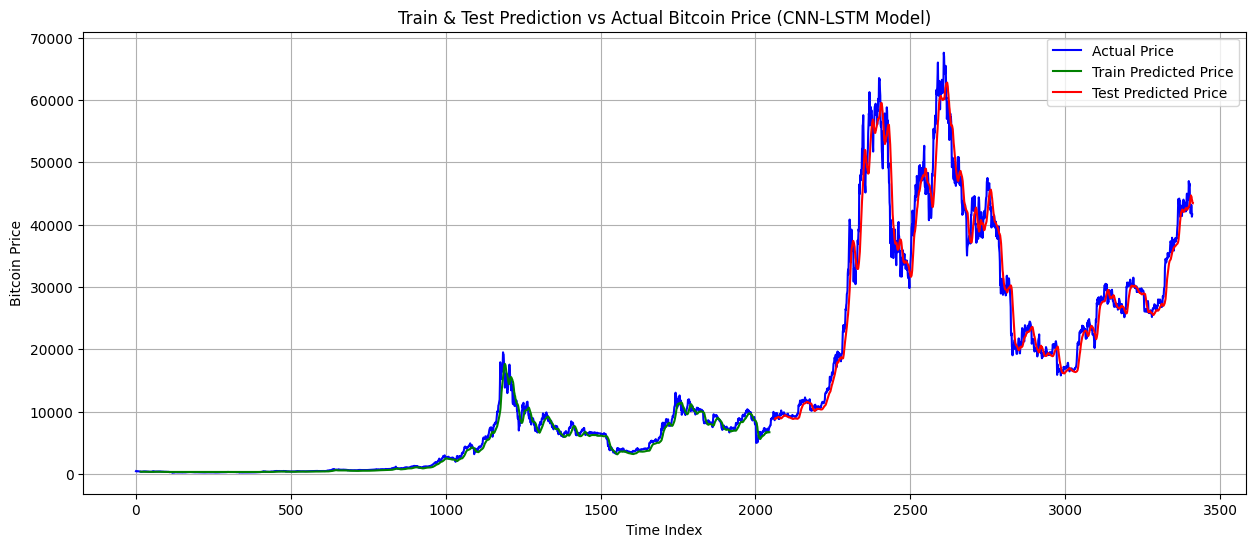

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Future Predicted Bitcoin Price: 42736.023


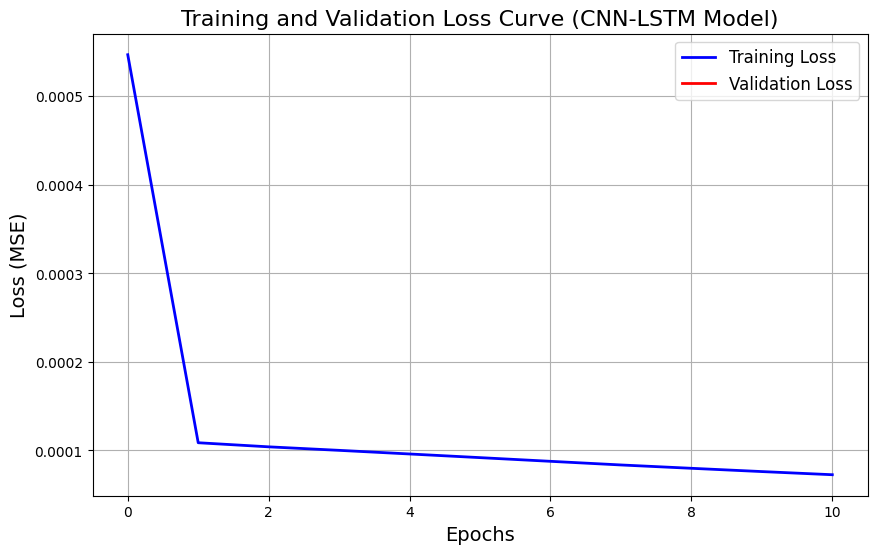

In [ ]:
## CNN + LSTM Hybrid model

import os
import pandas as pd
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

import plotly.graph_objects as go
import plotly.express as px

# Ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
maindf = pd.read_csv("/content/drive/MyDrive/BTC-USD (2014-2024).csv")
closedf = maindf[['Date','Close']]

# Plot initial data
fig = px.line(closedf, x=closedf.Date, y=closedf.Close,
              labels={'date':'Date','close':'Close Stock'})
fig.update_layout(title_text='Whole period of timeframe of Bitcoin close price 2014-2024')
fig.show()

# Preprocessing
del closedf['Date']
scaler = MinMaxScaler(feature_range=(0,1))
closedf = scaler.fit_transform(np.array(closedf).reshape(-1,1))

training_size = int(len(closedf)*0.60)
test_size = len(closedf) - training_size
train_data, test_data = closedf[0:training_size], closedf[training_size:]

# Dataset preparation
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 15
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN-LSTM Hybrid model
model = Sequential()
model.add(Input(shape=(time_step, 1)))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(50, activation='tanh'))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam")

# Fit model with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=150, batch_size=32, verbose=1, callbacks=[early_stop])

# Predict and inverse scale
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Handle potential NaNs in predictions before inverse scaling
train_predict = np.nan_to_num(train_predict, nan=0.0)
test_predict = np.nan_to_num(test_predict, nan=0.0)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1, 1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1, 1))

# Handle potential NaNs in the original target values as well
original_ytrain = np.nan_to_num(original_ytrain, nan=0.0)
original_ytest = np.nan_to_num(original_ytest, nan=0.0)

# Evaluation
print("Train data RMSE:", math.sqrt(mean_squared_error(original_ytrain, train_predict)))
print("Test data RMSE: ", math.sqrt(mean_squared_error(original_ytest, test_predict)))

# Mean Absolute Percentage Error (MAPE) based accuracy
def calculate_accuracy(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    mask = actual > 1e-8
    if np.sum(mask) == 0:
        return 0
    filtered_actual = actual[mask]
    filtered_predicted = predicted[mask]
    mape = np.mean(np.abs((filtered_actual - filtered_predicted) / filtered_actual)) * 100
    accuracy = 100 - mape
    return accuracy

train_accuracy = calculate_accuracy(original_ytrain, train_predict)
test_accuracy = calculate_accuracy(original_ytest, test_predict)

print("Train data Accuracy (based on MAPE): {:.2f}%".format(train_accuracy))
print("Test data Accuracy (based on MAPE):  {:.2f}%".format(test_accuracy))

# Create prediction placeholders for plotting
train_predict_plot = np.empty_like(closedf)
train_predict_plot[:, :] = np.nan
train_predict_plot[time_step:training_size-1, :] = train_predict

test_predict_plot = np.empty_like(closedf)
test_predict_plot[:, :] = np.nan
test_predict_plot[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict), :] = test_predict

# Actual inverse-scaled data for comparison
actual_data_plot = scaler.inverse_transform(closedf)

# Plot using Matplotlib
plt.figure(figsize=(15,6))
plt.plot(actual_data_plot, label='Actual Price', color='blue')
plt.plot(train_predict_plot, label='Train Predicted Price', color='green')
plt.plot(test_predict_plot, label='Test Predicted Price', color='red')
plt.xlabel("Time Index")
plt.ylabel("Bitcoin Price")
plt.title("Train & Test Prediction vs Actual Bitcoin Price (CNN-LSTM Model)")
plt.legend()
plt.grid(True)
plt.show()

# Interactive Plotly chart
time_index = maindf['Date']
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_index, y=actual_data_plot.flatten(), mode='lines', name='Actual Price', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=time_index[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict)],
                         y=test_predict.flatten(), mode='lines', name='Test Predicted Price', line=dict(color='red')))
fig.update_layout(title='Actual vs Predicted Bitcoin Price (2014–2024) - CNN-LSTM',
                  xaxis_title='Date', yaxis_title='Price',
                  plot_bgcolor='white')
fig.show()

# Prediction for future value
x_input = test_data[-time_step:].reshape(1, -1)
x_input = x_input.reshape((1, time_step, 1))
future_pred = model.predict(x_input)
future_pred_value = scaler.inverse_transform(future_pred)
print("Future Predicted Bitcoin Price:", future_pred_value[0][0])


# Plot Training and Validation Loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss Curve (CNN-LSTM Model)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


In [ ]:
## CNN-LSTM model forecasting for next 30 days

if np.isnan(x_input).any():
    nan_indices = np.where(np.isnan(x_input))
    for i in range(len(nan_indices[0])):
        idx = nan_indices[1][i]
        valid_values = x_input[0][~np.isnan(x_input[0, :, 0]), 0]
        x_input[0, idx, 0] = np.mean(valid_values)

print("x_input shape:", x_input.shape)
print("x_input:", x_input)
print("NaNs in x_input?", np.isnan(x_input).any())
print("Infs in x_input?", np.isinf(x_input).any())

x_input = test_data[-time_step:].reshape(1, time_step, 1)

# Reshape last time_step data from test_data for prediction
x_input = test_data[-time_step:].reshape(1, time_step, 1)

# Sanitize just in case
x_input = np.nan_to_num(x_input, nan=0.0, posinf=0.0, neginf=0.0)

# Predict and inverse transform
future_pred = model.predict(x_input)
future_pred_value = scaler.inverse_transform(future_pred)

print("Future Predicted Bitcoin Price:", future_pred_value[0][0])

# Start with last time_step days from test_data
temp_input = list(test_data[-time_step:].flatten())
temp_input = [x if not np.isnan(x) else 0.0 for x in temp_input]
future_output = []
n_steps = time_step
future_days = 30
for i in range(future_days):
    x_input = np.array(temp_input[-n_steps:]).reshape(1, n_steps, 1)
    y_pred = model.predict(x_input, verbose=0)
    temp_input.append(y_pred[0][0])
    future_output.append(y_pred[0][0])
future_output = scaler.inverse_transform(np.array(future_output).reshape(-1, 1))
last_date = pd.to_datetime(maindf['Date'].iloc[-1])
future_dates = [last_date + dt.timedelta(days=i+1) for i in range(future_days)]

# Convert future_dates to strings for Matplotlib
future_dates_str = [d.strftime('%Y-%m-%d') for d in future_dates]

#Plot predictions

last_date = pd.to_datetime(maindf['Date'].iloc[-1])
future_days = 30
future_dates = [last_date + dt.timedelta(days=i+1) for i in range(future_days)]
time_index = maindf['Date']
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_index, y=scaler.inverse_transform(closedf).flatten(),
                         mode='lines', name='Historical Price', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=time_index[training_size + time_step + 1:training_size + time_step + 1 + len(test_predict)],
                         y=test_predict.flatten(), mode='lines',
                         name='Test Predicted Price', line=dict(color='red')))
fig.add_trace(go.Scatter(x=future_dates, y=future_output.flatten(),
                         mode='lines', name='Next 30-Day Forecast', line=dict(color='orange', dash='dash')))  # Use dash for linestyle
fig.update_layout(title='Bitcoin Price Forecast for Next 30 Days [CNN+LSTM Model]',
                  xaxis_title='Date', yaxis_title='Price',
                  plot_bgcolor='white')
fig.show()

# Create DataFrame for next 30 days forecast
forecast_df = pd.DataFrame({
    'Date': future_dates_str,
    'Predicted Price': future_output.flatten()
})

# Display the DataFrame
print(forecast_df)


x_input shape: (1, 15, 1)
x_input: [[[0.60880387]
  [0.6074985 ]
  [0.6059457 ]
  [0.6046485 ]
  [0.6032679 ]
  [0.601952  ]
  [0.60066617]
  [0.599325  ]
  [0.5980439 ]
  [0.5966808 ]
  [0.59539473]
  [0.59404653]
  [0.5927467 ]
  [0.59140736]
  [0.5900987 ]]]
NaNs in x_input? False
Infs in x_input? False
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Future Predicted Bitcoin Price: 42885.703


          Date  Predicted Price
0   2024-01-22     42885.703125
1   2024-01-23     42497.367188
2   2024-01-24     42470.472656
3   2024-01-25     42171.785156
4   2024-01-26     42112.804688
5   2024-01-27     41930.503906
6   2024-01-28     41906.148438
7   2024-01-29     41828.007812
8   2024-01-30     41753.339844
9   2024-01-31     41657.261719
10  2024-02-01     41572.726562
11  2024-02-02     41512.171875
12  2024-02-03     41414.769531
13  2024-02-04     41331.261719
14  2024-02-05     41204.621094
15  2024-02-06     41116.656250
16  2024-02-07     41012.011719
17  2024-02-08     40924.593750
18  2024-02-09     40831.558594
19  2024-02-10     40742.882812
20  2024-02-11     40656.230469
21  2024-02-12     40565.851562
22  2024-02-13     40479.519531
23  2024-02-14     40387.664062
24  2024-02-15     40300.996094
25  2024-02-16     40210.140625
26  2024-02-17     40122.546875
27  2024-02-18     40032.292969
28  2024-02-19     39944.101562
29  2024-02-20     39855.902344
